In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported!")

All libraries imported!


In [13]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Dataset loaded!")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Dataset loaded!
Rows: 7043, Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
print("=== COLUMN NAMES ===")
print(list(df.columns))

print("\n=== DATA TYPES & MISSING VALUES ===")
df.info()

=== COLUMN NAMES ===
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

=== DATA TYPES & MISSING VALUES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   ob

=== CHURN STATISTICS ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.5%


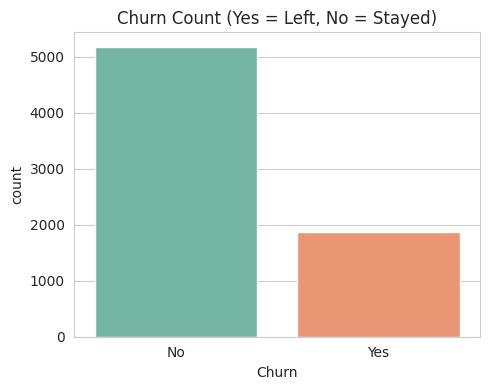

In [15]:
print("=== CHURN STATISTICS ===")
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")

plt.figure(figsize=(5,4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Count (Yes = Left, No = Stayed)')
plt.tight_layout()
plt.show()

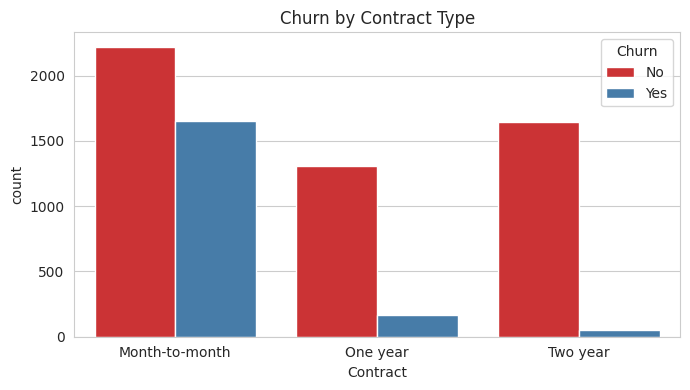

Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%
Name: Yes, dtype: object


In [16]:
plt.figure(figsize=(7,4))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set1')
plt.title('Churn by Contract Type')
plt.tight_layout()
plt.show()

print(df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()['Yes'].apply(lambda x: f"{x*100:.1f}%"))

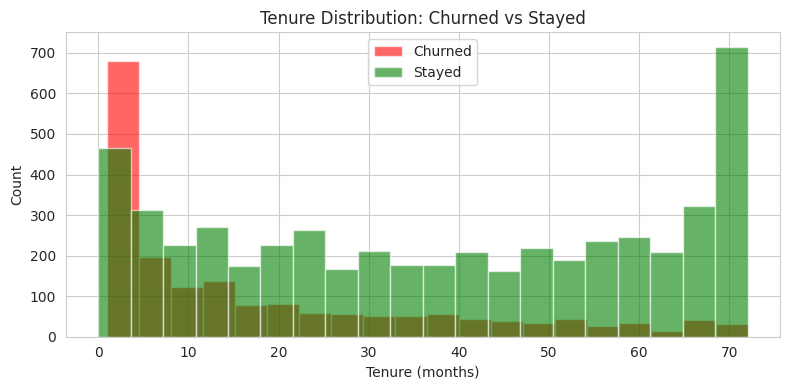

In [17]:
plt.figure(figsize=(8,4))
df[df['Churn']=='Yes']['tenure'].hist(alpha=0.6, color='red',   bins=20, label='Churned')
df[df['Churn']=='No']['tenure'].hist(alpha=0.6, color='green', bins=20, label='Stayed')
plt.title('Tenure Distribution: Churned vs Stayed')
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

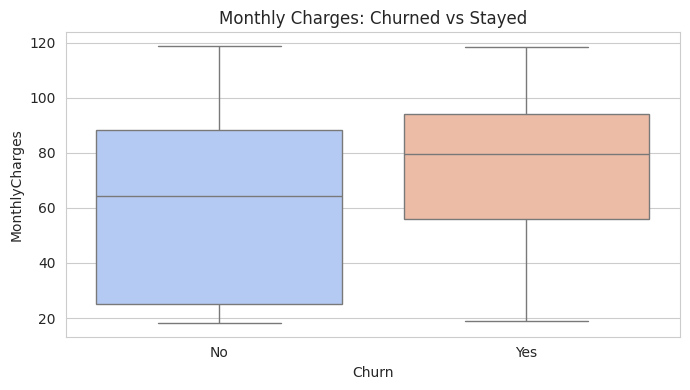

Avg monthly charge (Churned): 74.44
Avg monthly charge (Stayed) : 61.27


In [18]:
plt.figure(figsize=(7,4))
sns.boxplot(x='Churn', data=df, y='MonthlyCharges', palette='coolwarm')
plt.title('Monthly Charges: Churned vs Stayed')
plt.tight_layout()
plt.show()

print("Avg monthly charge (Churned):", df[df['Churn']=='Yes']['MonthlyCharges'].mean().round(2))
print("Avg monthly charge (Stayed) :", df[df['Churn']=='No']['MonthlyCharges'].mean().round(2))

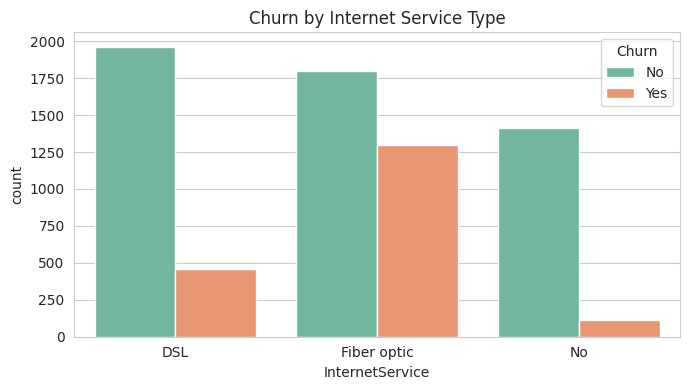

In [19]:
plt.figure(figsize=(7,4))
sns.countplot(x='InternetService', hue='Churn', data=df, palette='Set2')
plt.title('Churn by Internet Service Type')
plt.tight_layout()
plt.show()

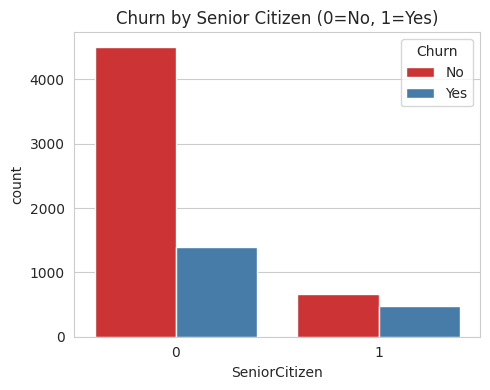

SeniorCitizen
0    23.6%
1    41.7%
Name: Yes, dtype: object


In [20]:
plt.figure(figsize=(5,4))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df, palette='Set1')
plt.title('Churn by Senior Citizen (0=No, 1=Yes)')
plt.tight_layout()
plt.show()

print(df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack()['Yes'].apply(lambda x: f"{x*100:.1f}%"))

In [21]:
df_clean = df.copy()

# TotalCharges is object type — convert to number
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

print("Missing values after conversion:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Missing values after conversion:
TotalCharges    11
dtype: int64


In [24]:
# Fill missing TotalCharges with median
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median())

print("Missing values fixed!")
print("Missing now:", df_clean.isnull().sum().sum())

Missing values fixed!
Missing now: 0


In [25]:
df_clean = df_clean.drop(columns=['customerID'])
print("customerID dropped!")
print("Shape:", df_clean.shape)

customerID dropped!
Shape: (7043, 20)


In [26]:
# Convert Churn: Yes=1, No=0
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})
print("Churn encoded!")
print(df_clean['Churn'].value_counts())

Churn encoded!
Churn
0    5174
1    1869
Name: count, dtype: int64


In [27]:
# Get all object/text columns
text_cols = df_clean.select_dtypes(include='object').columns.tolist()
print("Columns to encode:", text_cols)

le = LabelEncoder()
for col in text_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

print("\All text converted to numbers!")
print(df_clean.dtypes)

Columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
\All text converted to numbers!
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


In [28]:
print("=== FINAL CLEAN DATASET ===")
print(f"Shape       : {df_clean.shape}")
print(f"Missing     : {df_clean.isnull().sum().sum()}")
print(f"Churn ratio : {df_clean['Churn'].mean()*100:.1f}% churned")
df_clean.head()

=== FINAL CLEAN DATASET ===
Shape       : (7043, 20)
Missing     : 0
Churn ratio : 26.5% churned


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [30]:
# 1. Charges per month of tenure (value-for-money score)
df_clean['ChargesPerTenure'] = df_clean['TotalCharges'] / (df_clean['tenure'] + 1)

# 2. Is new customer? (tenure < 12 months)
df_clean['IsNewCustomer'] = (df_clean['tenure'] < 12).astype(int)

# 3. Is long-term customer? (tenure > 48 months)
df_clean['IsLoyalCustomer'] = (df_clean['tenure'] > 48).astype(int)

# 4. High spender? (monthly charges above median)
median_charge = df_clean['MonthlyCharges'].median()
df_clean['IsHighSpender'] = (df_clean['MonthlyCharges'] > median_charge).astype(int)

print("4 new features created!")
print(f"New shape: {df_clean.shape}")

4 new features created!
New shape: (7043, 24)


In [31]:
new_features = ['ChargesPerTenure', 'IsNewCustomer', 'IsLoyalCustomer', 'IsHighSpender']

for feat in new_features:
    corr = df_clean[feat].corr(df_clean['Churn'])
    print(f"{feat:25s} → correlation with Churn: {corr:+.3f}")

ChargesPerTenure          → correlation with Churn: +0.015
IsNewCustomer             → correlation with Churn: +0.318
IsLoyalCustomer           → correlation with Churn: -0.263
IsHighSpender             → correlation with Churn: +0.196


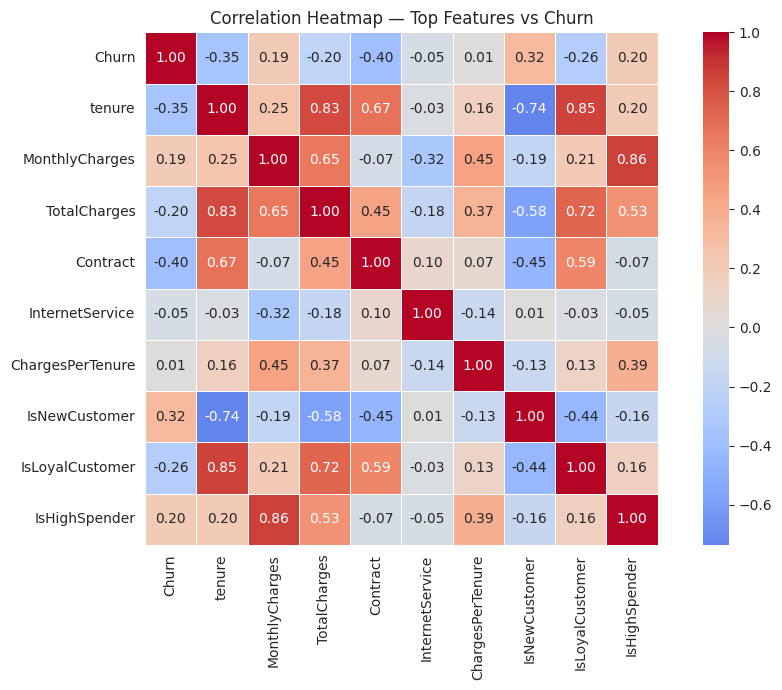

In [32]:
top_cols = ['Churn', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Contract',
            'InternetService', 'ChargesPerTenure', 'IsNewCustomer',
            'IsLoyalCustomer', 'IsHighSpender']

plt.figure(figsize=(10, 7))
sns.heatmap(df_clean[top_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Top Features vs Churn')
plt.tight_layout()
plt.show()

In [34]:
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

print("Features and Target created!")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Features and Target created!
X shape: (7043, 23)
y shape: (7043,)


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train/Test split done!")
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"Churn in train   : {y_train.mean()*100:.1f}%")
print(f"Churn in test    : {y_test.mean()*100:.1f}%")

Train/Test split done!
Training samples : 5634
Testing samples  : 1409
Churn in train   : 26.5%
Churn in test    : 26.5%


In [37]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc  = accuracy_score(y_test, lr_pred)
lr_auc  = roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])

print("=== LOGISTIC REGRESSION ===")
print(f"Accuracy : {lr_acc*100:.2f}%")
print(f"AUC Score: {lr_auc:.3f}")

=== LOGISTIC REGRESSION ===
Accuracy : 80.48%
AUC Score: 0.847


In [38]:
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base.fit(X_train, y_train)
rf_pred = rf_base.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
rf_auc  = roc_auc_score(y_test, rf_base.predict_proba(X_test)[:,1])

print("=== RANDOM FOREST (baseline) ===")
print(f"Accuracy : {rf_acc*100:.2f}%")
print(f"AUC Score: {rf_auc:.3f}")

=== RANDOM FOREST (baseline) ===
Accuracy : 78.71%
AUC Score: 0.821


In [39]:
# GridSearchCV tries every combination and finds the BEST settings!
param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2]
}

print("⏳ Running GridSearchCV — this takes 2-3 minutes, please wait...")

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,               # 5-fold cross validation
    scoring='accuracy',
    n_jobs=-1,          # use all CPU cores
    verbose=1
)
grid_search.fit(X_train, y_train)

print("\n✅ GridSearchCV complete!")
print("Best parameters found:")
print(grid_search.best_params_)
print(f"Best CV Accuracy: {grid_search.best_score_*100:.2f}%")

⏳ Running GridSearchCV — this takes 2-3 minutes, please wait...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ GridSearchCV complete!
Best parameters found:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Accuracy: 80.00%


In [40]:
best_model = grid_search.best_estimator_
best_pred  = best_model.predict(X_test)
best_acc   = accuracy_score(y_test, best_pred)
best_auc   = roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1])

print("=== TUNED RANDOM FOREST (GridSearchCV) ===")
print(f"Accuracy : {best_acc*100:.2f}%")
print(f"AUC Score: {best_auc:.3f}")

=== TUNED RANDOM FOREST (GridSearchCV) ===
Accuracy : 80.20%
AUC Score: 0.840


In [41]:
print("=" * 50)
print("         FINAL MODEL COMPARISON")
print("=" * 50)
print(f"{'Model':<30} {'Accuracy':>10} {'AUC':>8}")
print("-" * 50)
print(f"{'Logistic Regression':<30} {lr_acc*100:>9.2f}% {lr_auc:>8.3f}")
print(f"{'Random Forest (baseline)':<30} {rf_acc*100:>9.2f}% {rf_auc:>8.3f}")
print(f"{'Random Forest (GridSearchCV)':<30} {best_acc*100:>9.2f}% {best_auc:>8.3f}")
print("=" * 50)

print("\n📊 Detailed Report (Best Model):")
print(classification_report(y_test, best_pred,
      target_names=['Stayed', 'Churned']))

         FINAL MODEL COMPARISON
Model                            Accuracy      AUC
--------------------------------------------------
Logistic Regression                80.48%    0.847
Random Forest (baseline)           78.71%    0.821
Random Forest (GridSearchCV)       80.20%    0.840

📊 Detailed Report (Best Model):
              precision    recall  f1-score   support

      Stayed       0.83      0.91      0.87      1035
     Churned       0.67      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



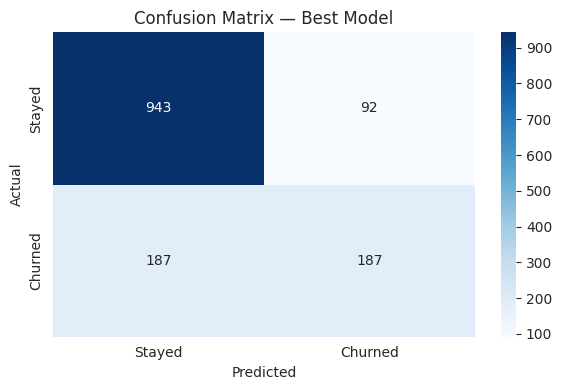

✅ Correctly identified churners   : 187
✅ Correctly identified loyal      : 943
❌ Missed churners (false negative): 187
❌ Wrong churn alerts (false pos)  : 92


In [42]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Confusion Matrix — Best Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"✅ Correctly identified churners   : {tp}")
print(f"✅ Correctly identified loyal      : {tn}")
print(f"❌ Missed churners (false negative): {fn}")
print(f"❌ Wrong churn alerts (false pos)  : {fp}")

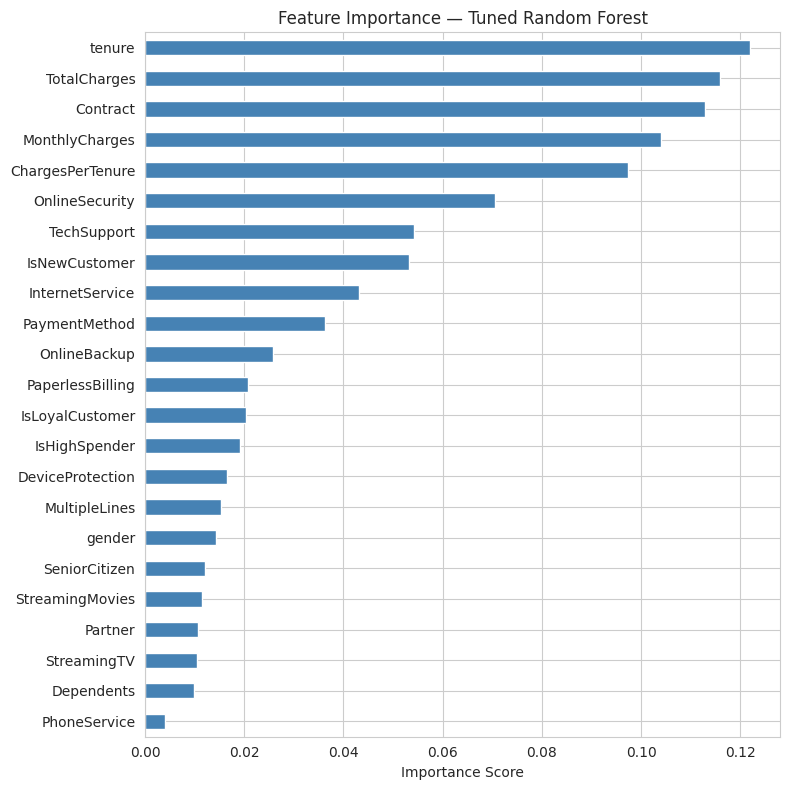


Top 5 most important features:
tenure              0.121921
TotalCharges        0.115898
Contract            0.112819
MonthlyCharges      0.103943
ChargesPerTenure    0.097395
dtype: float64


In [43]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 8))
importance.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature Importance — Tuned Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importance.sort_values(ascending=False).head(5))